# 乾物バンド × 区間線形GAM ─ 高含水帯(MC>120%)特化モデル【最終版】

**役割**: 高含水帯(MC>120%)専用の推定器(MC≤120% はアンサンブルの他モデル担当)。
評価指標は **LOSOでの MC>120 サンプルRMSE**(全樹種プール, n=146)。

**最良モデル(決定)**: 特徴 = 乾物 **mean+slope混合5**、基底 = **区間線形(線形スプライン) K=8, α=1**。
→ **MC>120 RMSE = 28.0**(内訳 120-200%=26.0 / >200%=39.7)。

選定経緯(詳細は `docs/dry_band_gauss_pwlinear_model.md`):
- 大域非線形(exp発散/quad符号反転/区間3次発散)は不可 → **裾が線形の局所基底**が安定。ガウス基底は平均回帰で外挿不能。
- 自然3次(macro向き,α30)は高MCで劣る(MC>120 RMSE 35.3)。**高MCは区間線形+弱正則化**。
- macroに効く b1210 は高MCで悪化のため不採用。データ駆動の貪欲特徴選択は選択リークで外挿を壊す → 特徴は事前固定。
- **>200% は乾物特徴の飽和で頭打ち**(SNVがスケールを消す)。生特徴は飽和を破るが樹種交絡でLOSO転移せず不採用。
- 高MC重み付け・冪変換ターゲット・凸裾はいずれも無効。

In [22]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.linear_model import Ridge

tr = pd.read_csv('../data/train_clean.csv', encoding='shift_jis')
META = ['sample number', 'species number', '樹種', '含水率']
wn_cols = [c for c in tr.columns if c not in META]
wn = np.array([float(c) for c in wn_cols]); wl = 1e7/wn; order = np.argsort(wl); nm = wl[order]
X = tr[wn_cols].values.astype(float)[:, order]
mc = tr['含水率'].values.astype(float); sp = tr['樹種'].values; species = np.unique(sp)
snv = lambda M: (M - M.mean(1, keepdims=True)) / (M.std(1, keepdims=True) + 1e-8)
sg = lambda M, d: savgol_filter(M, 11, 2, deriv=d, axis=1)
S, S1, S2 = snv(X), sg(snv(X), 1), sg(snv(X), 2)
bd = lambda M, lo, hi: M[:, (nm >= lo) & (nm <= hi)].mean(1)            # 帯域平均
def bslope(M, lo, hi):                                                  # 帯域内の波長傾き
    m = (nm >= lo) & (nm <= hi); w = nm[m] - nm[m].mean()
    return (M[:, m] * w).sum(1) / ((w**2).sum() + 1e-12)
# 採用特徴: 乾物 mean+slope混合5 (事前固定, 選択リーク無し)
Fmat = np.column_stack([bd(S1, 1260, 1300), bslope(S, 1260, 1300), bd(S2, 2200, 2240),
                        bd(S2, 2300, 2340), bd(S, 2340, 2400)])
fnames = ['CH1270_mean', 'CH1270_slope', 'CH2210_mean', 'CH2320_mean', 'CL2360_mean']
print('F', Fmat.shape, '| MC %.1f-%.1f%% | 特徴:', fnames)

F (1270, 5) | MC %.1f-%.1f%% | 特徴: ['CH1270_mean', 'CH1270_slope', 'CH2210_mean', 'CH2320_mean', 'CL2360_mean']


## 最良モデル: 区間線形(線形スプライン)GAM + Ridge
各特徴を切断べき基底 `{z, (z-t_k)₊}` で展開 → 両端は線形外挿(発散しない)。
標準化・ノットは各 fold の学習側のみで fit(リーク無し)。LOSOで各樹種を hold-out して予測。

In [23]:
class Std:
    def fit(self, A): self.mu = A.mean(0); self.sd = A.std(0) + 1e-9; return self
    def z(self, A): return (A - self.mu) / self.sd

def hinge_basis(Z, knots):                            # 区間線形 {z, (z-t_k)₊}
    return np.hstack([np.hstack([Z[:, [j]], np.maximum(0.0, Z[:, [j]] - knots[j][None, :])])
                      for j in range(Z.shape[1])])

def make_knots(Z, K):                                 # 学習側の分位点ノット
    qs = np.linspace(0.05, 0.95, K)
    return [np.quantile(Z[:, j], qs) for j in range(Z.shape[1])]

def loso_pred(K=8, alpha=1.0):                        # LOSO予測ベクトル(区間線形)
    pred = np.zeros(len(mc))
    for s in species:
        te = sp == s; trn = ~te
        st = Std().fit(Fmat[trn]); Ztr, Zte = st.z(Fmat[trn]), st.z(Fmat[te])
        kn = make_knots(Ztr, K); ps = Std().fit(hinge_basis(Ztr, kn))
        pred[te] = Ridge(alpha).fit(ps.z(hinge_basis(Ztr, kn)), mc[trn]).predict(ps.z(hinge_basis(Zte, kn)))
    return pred

HI = mc > 120
def hi_scores(pred):
    r = lambda m: np.sqrt(np.mean((pred[m] - mc[m])**2))
    return r(HI), r((mc > 120) & (mc <= 200)), r(mc > 200), r((sp == 'ベイスギ') & HI)

pred = loso_pred(8, 1.0)                              # ★ 採用モデル
print('採用: 区間線形 K=8 α=1 | MC>120 件数 %d' % HI.sum())
print('  MC>120 RMSE = %.2f  (120-200=%.2f / >200=%.1f / ベイスギ>120=%.1f)' % hi_scores(pred))

採用: 区間線形 K=8 α=1 | MC>120 件数 146
  MC>120 RMSE = 28.03  (120-200=25.97 / >200=39.7 / ベイスギ>120=36.9)


### K×α の確認(MC>120 RMSE 最小が K=8, α=1)

In [24]:
tab = pd.DataFrame([[K, a, *hi_scores(loso_pred(K, a))[:3]] for K in [6, 8, 10, 12] for a in [0.3, 1.0, 2.0, 3.0]],
                   columns=['K', 'α', 'MC>120', '120-200', '>200'])
display(tab.sort_values('MC>120').head(8).round(2).reset_index(drop=True))

,K,α,MC>120,120-200,>200
0,8,1.0,28.03,25.97,39.70
1,6,1.0,28.05,26.17,38.91
2,8,2.0,28.21,26.12,40.05
3,12,1.0,28.22,25.91,41.04
4,12,2.0,28.23,25.89,41.23
5,6,2.0,28.36,26.40,39.57
6,12,3.0,28.39,25.97,41.71
7,6,0.3,28.40,26.01,41.63


## 真値 vs 推定値(MC>120)
**左**: 予測 vs 真値の散布(対角=完全一致, 点線=120%閾値)。MC>120を強調。
**中**: MC>120 を樹種色で(橙帯=飽和域 >200%, ここでプラトー化)。
**右**: 帯域別RMSE(120-200% は可解, >200% は頭打ち)。

findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font fa

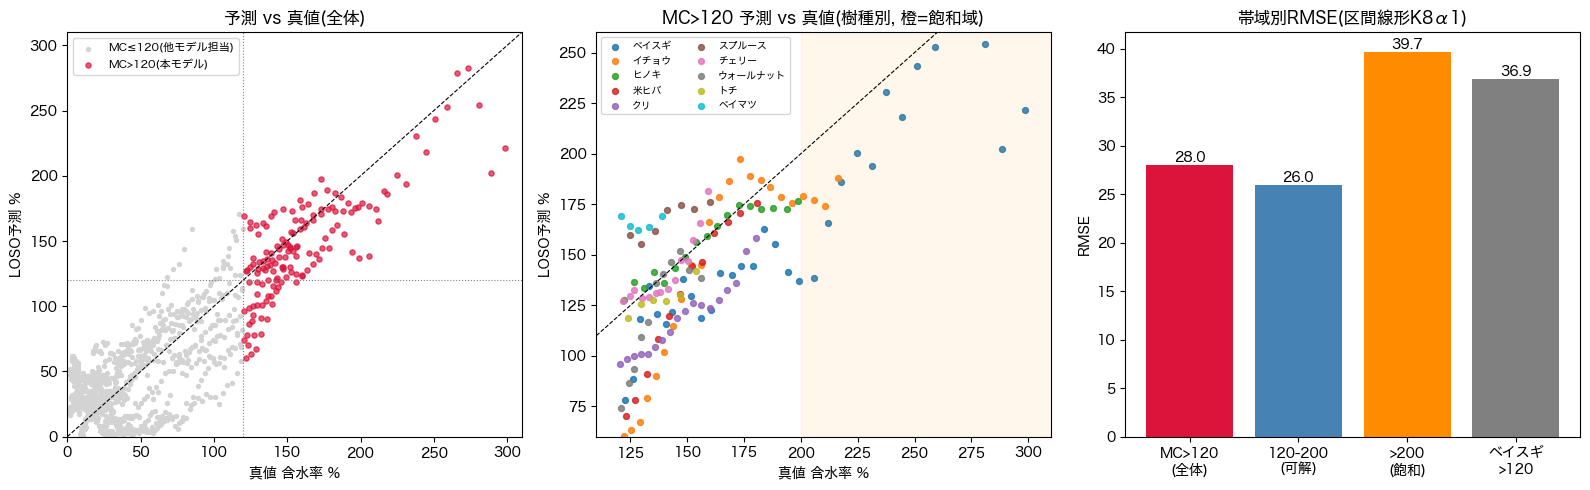

In [25]:
plt.rcParams['font.family'] = ['Hiragino Sans', 'Yu Gothic', 'Meiryo', 'IPAexGothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
lim = [0, 310]
ax[0].scatter(mc[~HI], pred[~HI], s=8, c='lightgray', label='MC≤120(他モデル担当)')
ax[0].scatter(mc[HI], pred[HI], s=14, c='crimson', alpha=.7, label='MC>120(本モデル)')
ax[0].plot(lim, lim, 'k--', lw=.8); ax[0].axvline(120, color='gray', ls=':', lw=.8); ax[0].axhline(120, color='gray', ls=':', lw=.8)
ax[0].set(xlim=lim, ylim=lim, xlabel='真値 含水率 %', ylabel='LOSO予測 %', title='予測 vs 真値(全体)')
ax[0].legend(fontsize=8)
hsp = sorted([s for s in species if ((sp == s) & HI).any()], key=lambda s: -mc[sp == s].max())
cmap = plt.cm.tab10(np.linspace(0, 1, len(hsp)))
for c, s in zip(cmap, hsp):
    m = (sp == s) & HI; ax[1].scatter(mc[m], pred[m], s=18, color=c, label=s, alpha=.85)
ax[1].plot([110, 310], [110, 310], 'k--', lw=.8); ax[1].axvspan(200, 310, color='orange', alpha=.08)
ax[1].set(xlim=[110, 310], ylim=[60, 260], xlabel='真値 含水率 %', ylabel='LOSO予測 %',
          title='MC>120 予測 vs 真値(樹種別, 橙=飽和域)')
ax[1].legend(fontsize=7, ncol=2)
rs = hi_scores(pred); bands = ['MC>120\n(全体)', '120-200\n(可解)', '>200\n(飽和)', 'ベイスギ\n>120']
bar = ax[2].bar(bands, rs, color=['crimson', 'steelblue', 'darkorange', 'gray'])
ax[2].bar_label(bar, fmt='%.1f'); ax[2].set(ylabel='RMSE', title='帯域別RMSE(区間線形K8α1)')
plt.tight_layout(); plt.show()

findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'IPAexGothic' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font fa

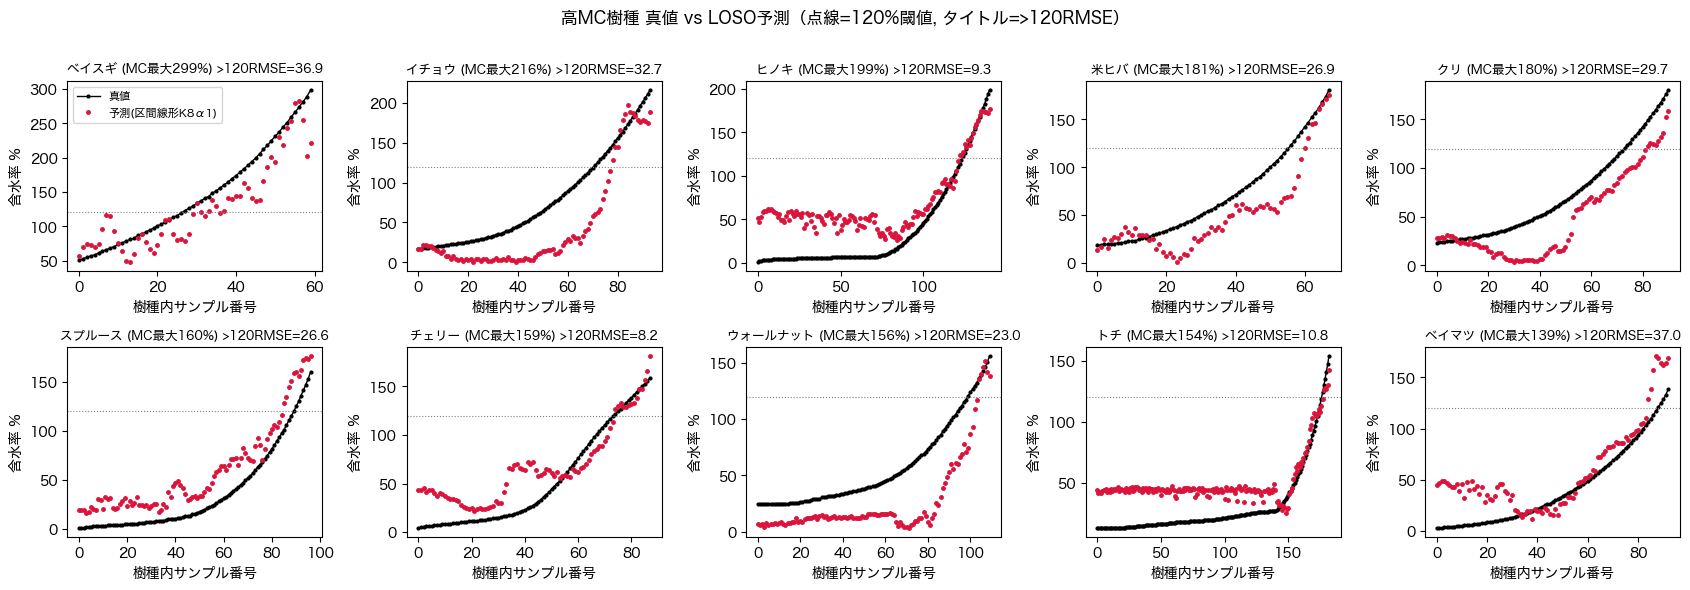

In [26]:
# 高MC樹種ごと: 樹種内サンプル番号(0始まり, 真値MC昇順) vs 含水率。真値と採用モデル予測を重ねる。
ncol = 5; nrow = int(np.ceil(len(hsp) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.4*ncol, 2.9*nrow)); axes = axes.ravel()
for axx, s in zip(axes, hsp):
    m = sp == s; o = np.argsort(mc[m]); idx = np.arange(m.sum())
    axx.plot(idx, mc[m][o], 'k.-', lw=1, ms=4, label='真値')
    axx.plot(idx, pred[m][o], '.', ms=5, color='crimson', label='予測(区間線形K8α1)')
    axx.axhline(120, color='gray', ls=':', lw=.8)
    hi = m & HI; r = np.sqrt(np.mean((pred[hi] - mc[hi])**2))
    axx.set_title('%s (MC最大%.0f%%) >120RMSE=%.1f' % (s, mc[m].max(), r), fontsize=9)
    axx.set_xlabel('樹種内サンプル番号'); axx.set_ylabel('含水率 %')
for axx in axes[len(hsp):]:
    axx.axis('off')
axes[0].legend(fontsize=8, loc='upper left')
fig.suptitle('高MC樹種 真値 vs LOSO予測（点線=120%閾値, タイトル=>120RMSE）', y=1.01, fontsize=12)
plt.tight_layout(); plt.show()

## なぜ >200% は頭打ちか(特徴飽和の診断)
「下に凸の裾なら追従するのでは?」への回答 → **裾の形ではなく乾物特徴の飽和**が原因。
(1) ベイスギ自身の低MC側だけで学習→高MC側を予測しても届かない。
(2) ベイスギ MC=259〜299% は特徴空間でほぼ同じ近傍(他樹種の実MC≈177%)に写る=MC増でも特徴が動かない。
→ 入力が動かない以上どんな裾関数でも持ち上げ不能。生特徴は飽和を破るが樹種交絡でLOSO転移せず(別途検証)。

In [27]:
from scipy.spatial.distance import cdist
ced = sp == 'ベイスギ'; oth = ~ced
ci = np.where(ced)[0]; o = ci[np.argsort(mc[ci])]; ntr = int(.6 * len(o))
m1 = Ridge(1.0).fit(Fmat[o[:ntr]], mc[o[:ntr]]).predict(Fmat[o[ntr:]])
print('(1)種内外挿 低MC学習→高MC予測: 真値%.0f-%.0f%% → 予測%.0f-%.0f%% (届かない)'
      % (mc[o[ntr:]].min(), mc[o[ntr:]].max(), m1.min(), m1.max()))
st = (Fmat - Fmat[oth].mean(0)) / (Fmat[oth].std(0) + 1e-9)
top = ci[np.argsort(mc[ci])][-6:]; D = cdist(st[top], st[oth])
for i, t in enumerate(top):
    nn = np.where(oth)[0][np.argsort(D[i])[:5]]
    print('   ベイスギ MC=%.0f%% → 特徴最近傍の他樹種の実MC %s' % (mc[t], [int(mc[k]) for k in nn]))

(1)種内外挿 低MC学習→高MC予測: 真値156-299% → 予測100-118% (届かない)
   ベイスギ MC=259% → 特徴最近傍の他樹種の実MC [172, 177, 167, 182, 182]
   ベイスギ MC=266% → 特徴最近傍の他樹種の実MC [172, 177, 167, 182, 182]
   ベイスギ MC=273% → 特徴最近傍の他樹種の実MC [172, 177, 182, 167, 182]
   ベイスギ MC=281% → 特徴最近傍の他樹種の実MC [172, 177, 182, 167, 182]
   ベイスギ MC=289% → 特徴最近傍の他樹種の実MC [177, 172, 182, 167, 163]
   ベイスギ MC=299% → 特徴最近傍の他樹種の実MC [177, 182, 172, 182, 210]


## 注意(リーク)
- 特徴・K・α は事前固定。乾物バンドは全train の高MC相関EDA・少数案比較で選定＝軽い楽観バイアス。
- ノット・標準化はすべて各 fold の学習側のみで fit 済み(リーク無し)。
- データ Shift-JIS, メタ列 `sample number, species number, 樹種, 含水率`、以降が波数(cm⁻¹)降順の吸光度。